In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr

## Cargamos los datos

In [14]:
df = pd.read_parquet(r"D:\DDAA\SimuladorEmpresarial\RRHH_220925_clean.parquet")
#pd.set_option("display.max_rows", None)
#pd.set_option("display.max_columns", None)
#df
df.dtypes

ID                                  int64
Reason_absence             string[python]
Month_absence              string[python]
Day_week                   string[python]
Seasons                    string[python]
Transportation_expense            float64
Distance_Residence_Work           float64
Service_time                      float64
Age                               float64
Work_load_Average_day             float64
Hit_target                        float64
Disciplinary_failure                int64
Education                  string[python]
Son                                 int64
Social_drinker                      int64
Social_smoker                       int64
Pet                                 int64
Weight                            float64
Height                            float64
Body_mass_index                   float64
Absenteeism_hours                 float64
Education_numeric                   int64
Month_absence_order                 int64
Day_week_order                    

# Plan de análisis

## Objetivo del análisis 

Determinar qué características de los empleados están asociadas con un mayor desempeñoo laboral.

Para tener una medida de desempeño laboral consideraremos lo siguiente (para cada trabajador): el promedio de hit_target, la suma de horas de absentismo (o el recuento de absencias), si han tenido alguna falta disciplinaria o no, el número de faltas injustificadas. 

## ¿Cómo integrar toda esta información?

### Opción 1: clustering 

Podemos hacer clusters con estas variables y tendremos distintos grupos de trabajadores según su desempeño. A continuación, miraremos las características personales de cada grupo para intentar extraer conclusiones. 

### Opción 2: creación de medida de desempeño

En base a información sobre otras empresas, dar un peso a las distintas variables para obtener una medida de desempeño. 

## Respondiendo a la pregunta "¿Cómo afectan las catacterísticas personales al desempeño?"

### Análisis descriptivo

Ver qué características tienen los distintos clusters

### Modelo predictivo

Creamos un modelo con la combinación de características personales que nos permitan explicar en mayor medida la asignación de un trabajador a un cluster. 

Esto nos permitirá predecir a qué grupo de trabajadores pertenecerá un nuevo empleado en base a sus características personales.

# Cálculo de variables a utilizar en el clustering

In [15]:
pd.set_option("display.max.columns", None)
# Calculamos la media de hit target de cada trabajador 
df['Hit_target_avg'] = df.groupby('ID')['Hit_target'].transform('mean')

# Calculamos la media de Work_load_Average_day de cada trabajador
df['Work_load_Average_day'] = df.groupby('ID')['Work_load_Average_day'].transform('mean')

# Calcular número d'absències per treballador
df['count_absenteeism'] = (
    (df['Absenteeism_hours'] != 0)  
    .groupby(df['ID'])              
    .transform('sum')               
)

# Calcular quantes absències injustificades té cada treballador
df["unjustified_absence"] = (
    (df["Reason_absence"] == "26")
    .groupby(df["ID"])
    .transform("sum")
)

# Suma total d'hores d'absència per treballador
df["sum_absenteeism_hours"] = df.groupby("ID")["Absenteeism_hours"].transform("sum")

# Determinem si en algun moment han tingut una falta disciplinària
df["Disciplinary_failure"] = df.groupby("ID")["Disciplinary_failure"].transform(lambda x: int(x.max()))

# Ens quedem amb una única observació per treballador
df = df.drop_duplicates(subset=["ID"], keep="last").reset_index(drop=True)

# Eliminem les variables que ja han perdut sentit
df = df.drop(columns=["Reason_absence","Month_absence", "Day_week", "Seasons","Hit_target","Absenteeism_hours","Education_numeric","Month_absence_order","Day_week_order","Seasons_order"])

# Passar les binàries a boolean
cat_vars = ['Social_drinker', 'Social_smoker', 'Disciplinary_failure']
for col in cat_vars:
    df[col] = df[col].astype(bool)

df.head()

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Hit_target_avg,count_absenteeism,unjustified_absence,sum_absenteeism_hours
0,6,189.0,29.0,13.0,33.0,274.829000,False,High school,2,False,False,2,69.0,167.0,25.0,94.875000,8,0,72.0
1,16,118.0,15.0,24.0,46.0,248.642500,False,High school,2,True,True,0,75.0,175.0,25.0,97.500000,2,0,16.0
2,25,235.0,16.0,8.0,32.0,254.817500,False,Postgraduate,0,False,False,0,75.0,178.0,25.0,95.600000,10,0,42.0
3,12,233.0,51.0,1.0,31.0,271.274000,False,Graduate,1,True,False,8,68.0,178.0,21.0,96.142857,7,0,34.0
4,27,184.0,42.0,7.0,27.0,299.956333,False,High school,0,False,False,0,58.0,167.0,21.0,95.166667,6,0,25.0


In [16]:
df.dtypes

ID                                  int64
Transportation_expense            float64
Distance_Residence_Work           float64
Service_time                      float64
Age                               float64
Work_load_Average_day             float64
Disciplinary_failure                 bool
Education                  string[python]
Son                                 int64
Social_drinker                       bool
Social_smoker                        bool
Pet                                 int64
Weight                            float64
Height                            float64
Body_mass_index                   float64
Hit_target_avg                    float64
count_absenteeism                   int64
unjustified_absence                 Int64
sum_absenteeism_hours             float64
dtype: object

In [17]:
# Què utilitzem, count d'absències o suma d'hores d'absència?

# Mirem la correlació per si de cas no fos massa alta i poguéssim utilitzar les dues:

from scipy.stats import spearmanr
r, pval = spearmanr(df["count_absenteeism"], df["sum_absenteeism_hours"])

print(f"Spearman correlation (r): {r:.3f}")
print(f"P-value: {pval:.3e}")


Spearman correlation (r): 0.772
P-value: 4.059e-28


# Clustering

In [18]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# Seleccionamos las columnas
dfClus = df[["ID","Hit_target_avg", "Disciplinary_failure", "sum_absenteeism_hours", "unjustified_absence"]].copy()

# Escalamos solo las columnas numéricas
num_cols = ["Hit_target_avg", "sum_absenteeism_hours", "unjustified_absence"]
X_num = dfClus[num_cols].values
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Reconstruimos X agregando la columna categórica (falta disciplinaria)
X = np.hstack([X_num_scaled, dfClus[["Disciplinary_failure"]].values])

# Ahora la columna categórica es la última
cat_cols = [3]

# Entrenar K-Prototypes
kproto = KPrototypes(n_clusters=4, random_state=42, init='Huang')
clusters = kproto.fit_predict(X, categorical=cat_cols)

# Guardar clusters en el DataFrame
dfClus["cluster_desempeno"] = clusters.astype(int)

resumen = dfClus.groupby("cluster_desempeno").agg({
    "Hit_target_avg": "mean",
    "Disciplinary_failure": "mean",   # será la proporción de 1s
    "sum_absenteeism_hours": "mean",
    "unjustified_absence": "mean",
    "cluster_desempeno": "count"                 # cantidad de empleados por cluster
}).rename(columns={"cluster_desempeno": "n_empleados"})
print(resumen)

# Imprimir cost
print("Cost del clustering:", kproto.cost_)

# Ver la distribución de clusters
print(dfClus["cluster_desempeno"].value_counts())

# Opcional: mostrar centroides
print("Centroides:")
print(kproto.cluster_centroids_)

                   Hit_target_avg  Disciplinary_failure  \
cluster_desempeno                                         
0                       94.621384              0.615385   
1                       93.381217              1.000000   
2                       90.574775              0.135135   
3                       96.480106              0.084337   

                   sum_absenteeism_hours  unjustified_absence  n_empleados  
cluster_desempeno                                                           
0                             270.230769                  1.0           13  
1                             286.000000             6.333333            3  
2                               8.135135             0.054054           37  
3                              14.265060             0.012048           83  
Cost del clustering: 120.4814272332333
cluster_desempeno
3    83
2    37
0    13
1     3
Name: count, dtype: int64
Centroides:
[[-1.80624556e-03  2.39934170e+00  6.97914028e-01  1.000

In [19]:
# Fem una nova columna al df per indicar a quin cluster pertany cada treballador: 

df = df.merge(dfClus[["ID", "cluster_desempeno"]].drop_duplicates(), on="ID", how="left")
df.head(20)

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Hit_target_avg,count_absenteeism,unjustified_absence,sum_absenteeism_hours,cluster_desempeno
0,6,189.0,29.0,13.0,33.0,274.829000,False,High school,2,False,False,2,69.0,167.0,25.0,94.875000,8,0,72.0,3
1,16,118.0,15.0,24.0,46.0,248.642500,False,High school,2,True,True,0,75.0,175.0,25.0,97.500000,2,0,16.0,3
2,25,235.0,16.0,8.0,32.0,254.817500,False,Postgraduate,0,False,False,0,75.0,178.0,25.0,95.600000,10,0,42.0,3
3,12,233.0,51.0,1.0,31.0,271.274000,False,Graduate,1,True,False,8,68.0,178.0,21.0,96.142857,7,0,34.0,3
4,27,184.0,42.0,7.0,27.0,299.956333,False,High school,0,False,False,0,58.0,167.0,21.0,95.166667,6,0,25.0,3
5,14,155.0,12.0,14.0,34.0,299.354379,False,High school,2,True,False,0,95.0,196.0,25.0,95.689655,29,0,476.0,0
6,26,300.0,26.0,13.0,43.0,247.717000,False,High school,2,True,True,1,77.0,175.0,25.0,95.400000,5,0,83.0,3
7,10,361.0,52.0,3.0,28.0,258.764348,False,High school,1,True,False,4,80.0,172.0,27.0,94.000000,23,0,178.0,0
8,32,289.0,48.0,29.0,49.0,309.128200,False,High school,0,False,False,2,108.0,172.0,36.0,92.600000,5,0,16.0,2
9,9,228.0,14.0,16.0,58.0,249.042250,False,High school,2,False,False,1,65.0,172.0,22.0,95.875000,8,0,262.0,0


In [20]:
# Diccionari de mapeig
cluster_map = {
    3: "Productius i estables",
    2: "Estables",
    1: "Ausents",
    0: "Critics"
}

# Aplicar el canvi
df['cluster_desempeno'] = df['cluster_desempeno'].map(cluster_map)


# Mirar la relació entre els clusters de característiques personals i els clusters de desempeño

## Clustering variables personals

In [21]:
df_pers = pd.read_parquet(r"D:\DDAA\SimuladorEmpresarial\RRHH_220925_clean.parquet")

## Cluster
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# Agrupar por ID 
df_orig = df_pers.groupby("ID").first()[[
    "Age", "Distance_Residence_Work", "Transportation_expense",
    "Son", "Education", "Social_drinker", "Social_smoker"
]].copy()

# Columnas numéricas y categóricas
num_cols = ["Age", "Distance_Residence_Work", "Transportation_expense", "Son"]
cat_cols = ["Education", "Social_drinker", "Social_smoker"]

# Preparamos un dataframe para K-Prototypes: escalamos SOLO las numéricas
df_kp = df_orig.copy()
scaler = StandardScaler()
df_kp[num_cols] = scaler.fit_transform(df_kp[num_cols])

# Aseguramos que las categóricas sean strings (requerido por k-prototypes)
for c in cat_cols:
    df_kp[c] = df_kp[c].astype(str)
# índices de columnas categóricas para k-prototypes
cat_idx = [df_kp.columns.get_loc(c) for c in cat_cols]

# Ejecutar K-Prototypes
kproto = KPrototypes(n_clusters=4, random_state=42, init='Cao')
clusters = kproto.fit_predict(df_kp.values, categorical=cat_idx)
df_orig["cluster"] = clusters

# Resumen numérico en unidades originales (medias)
cluster_num_summary = df_orig.groupby("cluster")[num_cols].mean()
print("Resumen numérico (unidades originales):")
print(cluster_num_summary.round(3))

# Resumen categórico: proporciones por cluster (por ejemplo % bebedores/fumadores y distribución de Education)
print("\nProporciones por cluster (categóricas):")
for c in cat_cols:
    prop = df_orig.groupby("cluster")[c].value_counts(normalize=True).unstack(fill_value=0)
    print(f"\n== {c} ==")
    print((prop*100).round(1))   # en porcentaje

# Modo (valor más frecuente) por cluster para las categóricas
mode_cat = df_orig.groupby("cluster")[cat_cols].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
print("\nModo (valor más frecuente) de las categóricas por cluster:")
print(mode_cat)

# Tamaño e IDs por cluster
print("\nTamaño por cluster:")
print(df_orig['cluster'].value_counts().sort_index())
print("\nIDs por cluster:")
for c in sorted(df_orig['cluster'].unique()):
    ids = df_orig[df_orig['cluster'] == c].index.tolist()
    print(f"\nCluster {c} ({len(ids)} empleados):")
    print(ids)


## Centroides y score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
# 1) Centroides interpretables
def mode_series(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

centroids_num = df_orig.groupby("cluster")[num_cols].mean()           # medias en unidades originales
centroids_cat = df_orig.groupby("cluster")[cat_cols].agg(mode_series) # moda de categóricas
centroids_readable = pd.concat([centroids_num, centroids_cat], axis=1)

print("\nCentroides interpretables (numérico = media; categórico = moda):")
print(centroids_readable.round(3))

# 2) Silhouette score - Opción A: SOLO numéricas escaladas
# usamos el scaler que ya tienes (entrenado sobre num_cols)
X_num_scaled = scaler.transform(df_orig[num_cols])   # df_orig tiene las num en unidades originales
sil_num = silhouette_score(X_num_scaled, df_orig['cluster'])
print(f"\nSilhouette (solo numéricas escaladas): {sil_num:.4f}")

# 3) Silhouette score - Opción B: numéricas + categóricas (One-Hot)
# Preparamos ColumnTransformer: escala numéricas y one-hot para categóricas
ct = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    remainder="drop"
)

# Nota: usamos df_orig (unidades originales); ColumnTransformer hará el scaling
X_mixed = ct.fit_transform(df_orig[num_cols + cat_cols])
sil_mixed = silhouette_score(X_mixed, df_orig['cluster'])
print(f"Silhouette (numéricas + one-hot categóricas): {sil_mixed:.4f}")

# 4) Tamaño por cluster y muestra de centroides internos de kproto (opcional)
print("\nTamaño por cluster:")
print(df_orig['cluster'].value_counts().sort_index())

# kproto.cluster_centroids_ existe pero tiene formato interno: 
# numéricas (centroides continuos) y categóricas (modas como índices)
try:
    kp_centroids = kproto.cluster_centroids_
    print("\nCentroides internos reportados por kproto (formato interno):")
    print(kp_centroids)
except Exception:
    pass

# 5) Mensajes interpretativos rápidos
print("""
NOTAS:
- Silhouette (A) usa sólo numéricas: rápido, pero ignora info categórica.
- Silhouette (B) usa numéricas + one-hot: más representativo para datos mixtos,
  aunque la dimensionalidad sube y puede afectar el valor.
- Interpretación de Silhouette: >0.5 bueno, 0.2-0.5 moderado, <0.2 débil.
- Los centroides 'readable' muestran la media (num) y la moda (cat) por cluster,
  úsalos para nominar/explicar cada cluster.
""")

# Imprimir cost
print("Cost del clustering:", kproto.cost_)

Resumen numérico (unidades originales):
            Age  Distance_Residence_Work  Transportation_expense    Son
cluster                                                                
0        33.682                   40.864                 311.682  2.818
1        31.020                   21.220                 204.660  0.700
2        44.100                   21.725                 227.300  1.375
3        37.625                   50.833                 192.750  0.083

Proporciones por cluster (categóricas):

== Education ==
Education  Graduate  High school  Master/Doctor  Postgraduate
cluster                                                      
0               0.0        100.0            0.0           0.0
1              10.0         64.0            0.0          26.0
2              12.5         82.5            5.0           0.0
3               8.3         91.7            0.0           0.0

== Social_drinker ==
Social_drinker     0     1
cluster                   
0               13.6  

### Incorporem el cluster personal a la taula

In [22]:
# Crear una taula de mapeig ID -> cluster
df_clusters = df_orig[["cluster"]].reset_index()
df_clusters.rename(columns={"cluster": "cluster_personal"}, inplace=True)

# Diccionari de mapeig
cluster_map = {
    3: "Adultos, casi sin hijos, transporte medio, muy bebedores",
    2: "Adultos, pocos hijos, distancia media, bebedores, algo fumadores",
    1: "Jovenes, pocos hijos, poco transporte, no beben ni fuman",
    0: "Jovenes adultos, muchos hijos, gasto transporte alto, bebedores"
}

# Aplicar el canvi
df_clusters['cluster_personal'] = df_clusters['cluster_personal'].map(cluster_map)

# Fer el join amb el dataframe original
df = df.merge(df_clusters, on="ID", how="left")

# Comprovar
df.head()


,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Hit_target_avg,count_absenteeism,unjustified_absence,sum_absenteeism_hours,cluster_desempeno,cluster_personal
0,6,189.0,29.0,13.0,33.0,274.829000,False,High school,2,False,False,2,69.0,167.0,25.0,94.875000,8,0,72.0,Productius i estables,"Jovenes, pocos hijos, poco transporte, no bebe..."
1,16,118.0,15.0,24.0,46.0,248.642500,False,High school,2,True,True,0,75.0,175.0,25.0,97.500000,2,0,16.0,Productius i estables,"Adultos, pocos hijos, distancia media, bebedor..."
2,25,235.0,16.0,8.0,32.0,254.817500,False,Postgraduate,0,False,False,0,75.0,178.0,25.0,95.600000,10,0,42.0,Productius i estables,"Jovenes, pocos hijos, poco transporte, no bebe..."
3,12,233.0,51.0,1.0,31.0,271.274000,False,Graduate,1,True,False,8,68.0,178.0,21.0,96.142857,7,0,34.0,Productius i estables,"Adultos, casi sin hijos, transporte medio, muy..."
4,27,184.0,42.0,7.0,27.0,299.956333,False,High school,0,False,False,0,58.0,167.0,21.0,95.166667,6,0,25.0,Productius i estables,"Jovenes, pocos hijos, poco transporte, no bebe..."


### Tabla de frecuencias

In [23]:
tabla_frec = pd.crosstab(df["cluster_desempeno"], df["cluster_personal"])
tabla_frec


cluster_personal,"Adultos, casi sin hijos, transporte medio, muy bebedores","Adultos, pocos hijos, distancia media, bebedores, algo fumadores","Jovenes adultos, muchos hijos, gasto transporte alto, bebedores","Jovenes, pocos hijos, poco transporte, no beben ni fuman"
cluster_desempeno,,,,
Ausents,0,1,2,0
Critics,1,4,2,6
Estables,5,12,8,12
Productius i estables,18,23,10,32


In [24]:
from scipy.stats import chi2_contingency, fisher_exact
# 2) Test Chi-cuadrado de independencia
chi2, p, dof, expected = chi2_contingency(tabla_frec)
print("\nResultados Chi-cuadrado:")
print(f"Chi2 = {chi2:.3f}")
print(f"Grados de libertad = {dof}")
print(f"p-valor = {p:.4f}")

# 3) Residuos estandarizados (para ver qué celdas contribuyen más)
residuos = (tabla_frec - expected) / np.sqrt(expected)
print("\nResiduos estandarizados:")
print(pd.DataFrame(residuos, index=tabla_frec.index, columns=tabla_frec.columns))


Resultados Chi-cuadrado:
Chi2 = 10.567
Grados de libertad = 9
p-valor = 0.3066

Residuos estandarizados:
cluster_personal       Adultos, casi sin hijos, transporte medio, muy bebedores  \
cluster_desempeno                                                                 
Ausents                                                        -0.727607          
Critics                                                        -0.854409          
Estables                                                       -0.598532          
Productius i estables                                           0.876094          

cluster_personal       Adultos, pocos hijos, distancia media, bebedores, algo fumadores  \
cluster_desempeno                                                                         
Ausents                                                         0.125245                  
Critics                                                         0.090249                  
Estables                       

# Opción 2: crear una medida de desempeño

En base a la información encontrada, hemos decidido dar el siguiente peso a cada variable: 

Desempeno=(0.45×hit_target_avg)+(0.20×total_horas)+(0.20×faltas_injustificades)+(0.15×f_disciplinaria). Pero atención porque la primera es positiva y el resto negativas. Además, tienen escalas muy distintas, por lo que se tendrán que normalizar. 

In [25]:
from sklearn.preprocessing import MinMaxScaler

# Variables a considerar
vars_pos = ['Hit_target_avg']  # positiva
vars_neg = ['sum_absenteeism_hours', 'unjustified_absence', 'Disciplinary_failure']  # negativas

# Normalizar todas entre 0 y 1
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[vars_pos + vars_neg]),
                         columns=vars_pos + vars_neg,
                         index=df.index)

# Invertir las negativas para que 1 = mejor desempeño
for col in vars_neg:
    df_scaled[col] = 1 - df_scaled[col]

# Calcular medida de desempeño (0–100)
df['medida_desempeno'] = (0.45*df_scaled['Hit_target_avg'] +
                          0.20*df_scaled['sum_absenteeism_hours'] +
                          0.20*df_scaled['unjustified_absence'] +
                          0.15*df_scaled['Disciplinary_failure']) *100


df.head(10)

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Hit_target_avg,count_absenteeism,unjustified_absence,sum_absenteeism_hours,cluster_desempeno,cluster_personal,medida_desempeno
0,6,189.0,29.0,13.0,33.0,274.829000,False,High school,2,False,False,2,69.0,167.0,25.0,94.875000,8,0,72.0,Productius i estables,"Jovenes, pocos hijos, poco transporte, no bebe...",86.662290
1,16,118.0,15.0,24.0,46.0,248.642500,False,High school,2,True,True,0,75.0,175.0,25.0,97.500000,2,0,16.0,Productius i estables,"Adultos, pocos hijos, distancia media, bebedor...",95.577731
2,25,235.0,16.0,8.0,32.0,254.817500,False,Postgraduate,0,False,False,0,75.0,178.0,25.0,95.600000,10,0,42.0,Productius i estables,"Jovenes, pocos hijos, poco transporte, no bebe...",89.735294
3,12,233.0,51.0,1.0,31.0,271.274000,False,Graduate,1,True,False,8,68.0,178.0,21.0,96.142857,7,0,34.0,Productius i estables,"Adultos, casi sin hijos, transporte medio, muy...",91.428571
4,27,184.0,42.0,7.0,27.0,299.956333,False,High school,0,False,False,0,58.0,167.0,21.0,95.166667,6,0,25.0,Productius i estables,"Jovenes, pocos hijos, poco transporte, no bebe...",89.366246
5,14,155.0,12.0,14.0,34.0,299.354379,False,High school,2,True,False,0,95.0,196.0,25.0,95.689655,29,0,476.0,Critics,"Jovenes, pocos hijos, poco transporte, no bebe...",71.724138
6,26,300.0,26.0,13.0,43.0,247.717000,False,High school,2,True,True,1,77.0,175.0,25.0,95.400000,5,0,83.0,Productius i estables,"Adultos, pocos hijos, distancia media, bebedor...",87.512605
7,10,361.0,52.0,3.0,28.0,258.764348,False,High school,1,True,False,4,80.0,172.0,27.0,94.000000,23,0,178.0,Critics,"Jovenes adultos, muchos hijos, gasto transport...",80.021008
8,32,289.0,48.0,29.0,49.0,309.128200,False,High school,0,False,False,2,108.0,172.0,36.0,92.600000,5,0,16.0,Estables,"Adultos, casi sin hijos, transporte medio, muy...",83.327731
9,9,228.0,14.0,16.0,58.0,249.042250,False,High school,2,False,False,1,65.0,172.0,22.0,95.875000,8,0,262.0,Critics,"Adultos, pocos hijos, distancia media, bebedor...",81.179097


## Correlaciones
### Correlación de las características personales con medida de desempeño (todas las variables laborales por separado)

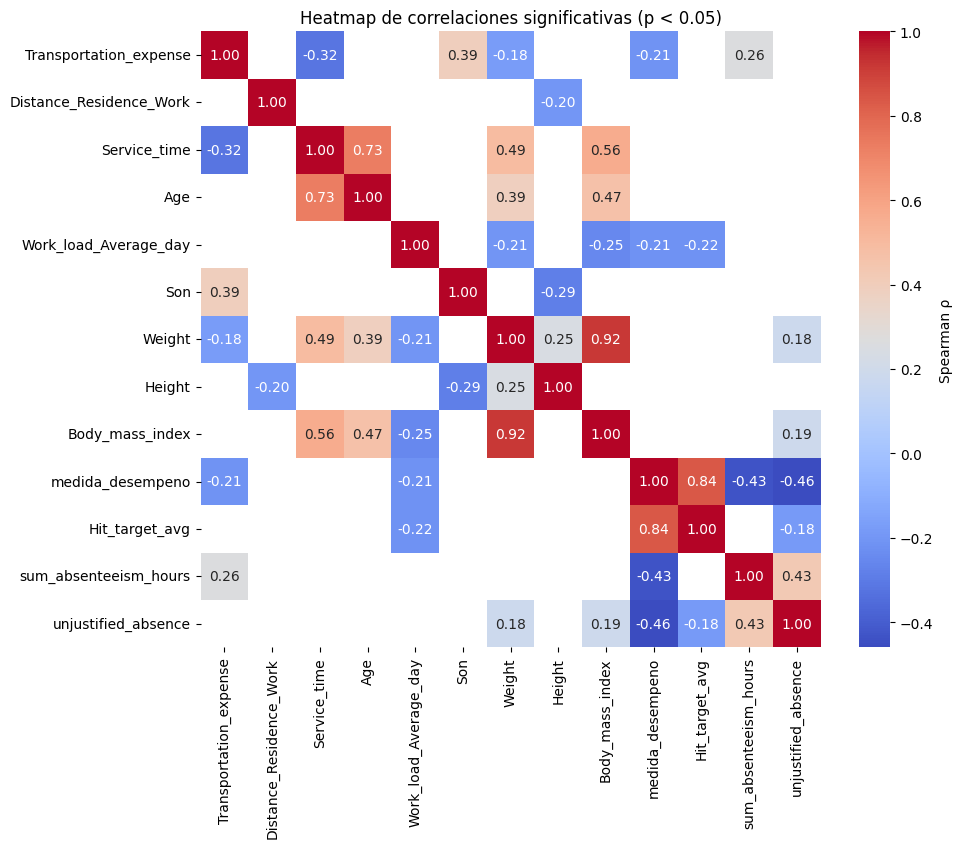

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# Variables de interés
vars_interes = [
    "Transportation_expense","Distance_Residence_Work","Service_time","Age",
    "Work_load_Average_day","Son","Weight","Height","Body_mass_index",
    "medida_desempeno","Hit_target_avg","sum_absenteeism_hours","unjustified_absence"
]

# Inicializar matrices de correlación y p-valores
n = len(vars_interes)
corr_matrix = pd.DataFrame(np.zeros((n, n)), index=vars_interes, columns=vars_interes)
pval_matrix = pd.DataFrame(np.zeros((n, n)), index=vars_interes, columns=vars_interes)

# Calcular rho y p-valor para cada par de variables
for i in range(n):
    for j in range(n):
        rho, pval = spearmanr(df[vars_interes[i]], df[vars_interes[j]], nan_policy="omit")
        corr_matrix.iloc[i, j] = rho
        pval_matrix.iloc[i, j] = pval

# Enmascarar las correlaciones no significativas
mask = pval_matrix >= 0.05
corr_sig = corr_matrix.mask(mask)

# Graficar heatmap solo con correlaciones significativas
plt.figure(figsize=(10, 8))
sns.heatmap(corr_sig, annot=True, fmt=".2f", cmap="coolwarm", mask=mask, cbar_kws={'label': 'Spearman ρ'})
plt.title("Heatmap de correlaciones significativas (p < 0.05)")
plt.show()




# Efecto de las variables personales sobre Disciplinary_failure

In [27]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# outcome column (binary)
outcome_col = "Disciplinary_failure"

# numeric variables you want to test
numeric_vars = [
    "Transportation_expense","Distance_Residence_Work","Service_time","Age",
    "Work_load_Average_day","Son","Weight","Height","Body_mass_index"
]

results = []

for var in numeric_vars:
    group0 = df.loc[df[outcome_col] == 0, var].dropna()
    group1 = df.loc[df[outcome_col] == 1, var].dropna()
    
    # Mann-Whitney U test
    stat, p_val = mannwhitneyu(group0, group1, alternative="two-sided")
    
    results.append({
        "variable": var,
        "U_statistic": stat,
        "p_value": p_val,
        "median_group0": group0.median(),
        "median_group1": group1.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Multiple testing correction (FDR by default)
reject, pvals_corrected, _, _ = multipletests(results_df["p_value"], 
                                              alpha=0.05, method="fdr_bh")

results_df["p_value_corrected"] = pvals_corrected
results_df["significant"] = reject

print(results_df)


                  variable  U_statistic   p_value  median_group0  \
0   Transportation_expense        770.0  0.001909        225.000   
1  Distance_Residence_Work       1537.5  0.165023         26.000   
2             Service_time       1371.5  0.675123         13.000   
3                      Age       1087.0  0.216097         36.000   
4    Work_load_Average_day       1185.0  0.507918        265.615   
5                      Son       1198.5  0.540803          1.000   
6                   Weight       1240.5  0.733070         76.000   
7                   Height       1454.5  0.364705        170.000   
8          Body_mass_index       1193.0  0.534636         25.000   

   median_group1  p_value_corrected  significant  
0     248.000000           0.017185         True  
1      25.000000           0.648290        False  
2      12.000000           0.733070        False  
3      38.000000           0.648290        False  
4     267.201571           0.695319        False  
5       1.000

## Relación entre desempeño/indicadores y variables categóricas

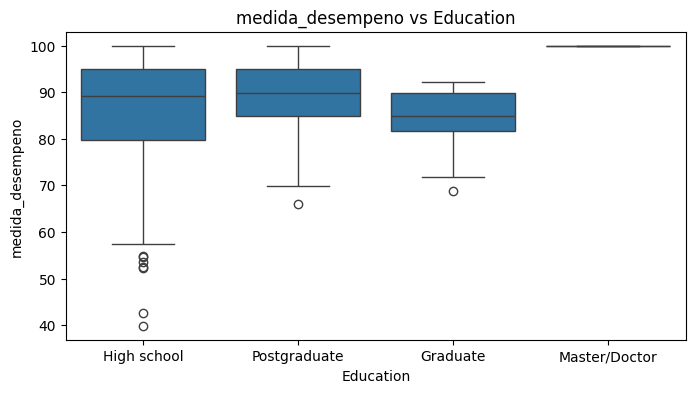

Education - p-value Kruskal-Wallis: 0.2564


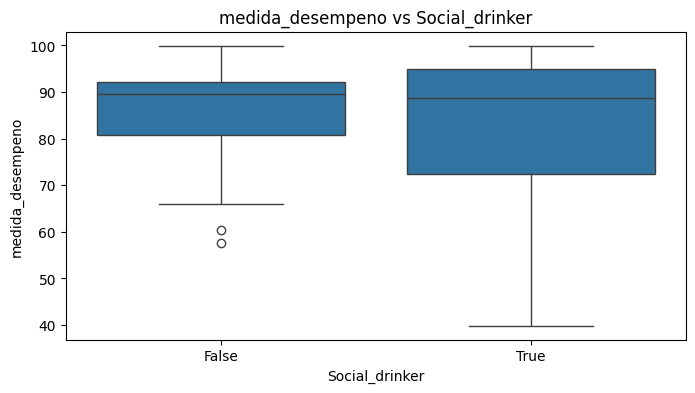

Social_drinker - p-value Mann-Whitney U: 0.9635


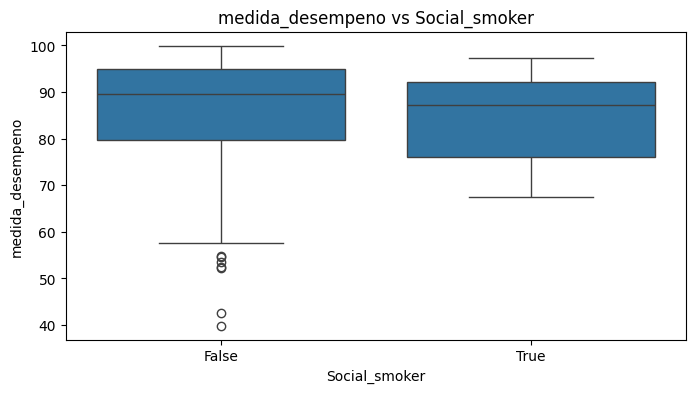

Social_smoker - p-value Mann-Whitney U: 0.6008


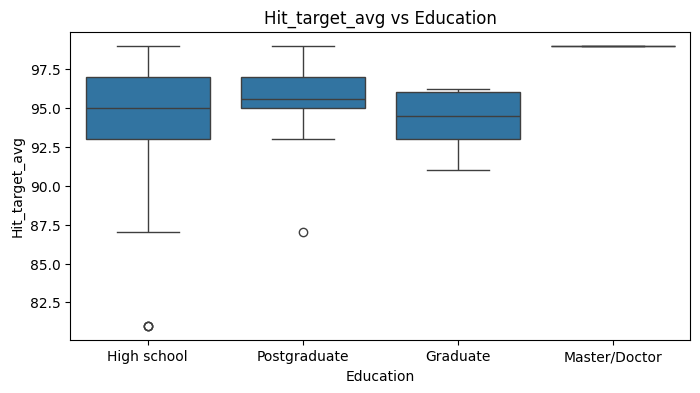

Education - p-value Kruskal-Wallis: 0.2119


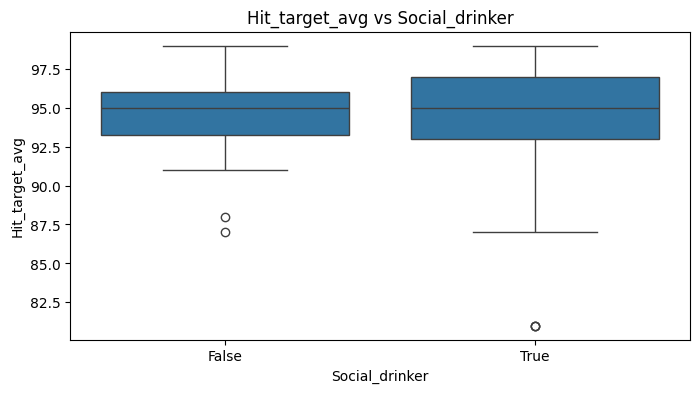

Social_drinker - p-value Mann-Whitney U: 0.8679


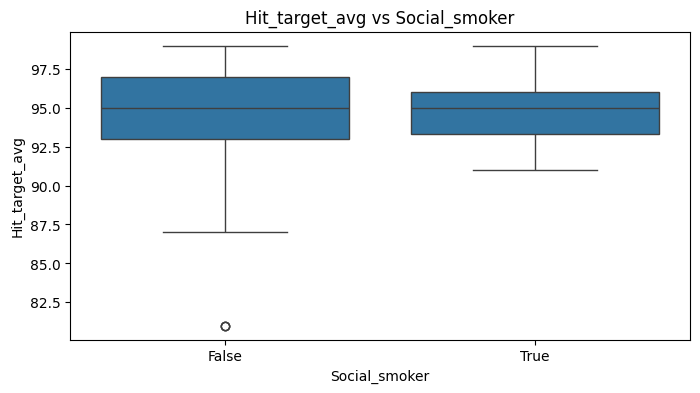

Social_smoker - p-value Mann-Whitney U: 0.9658


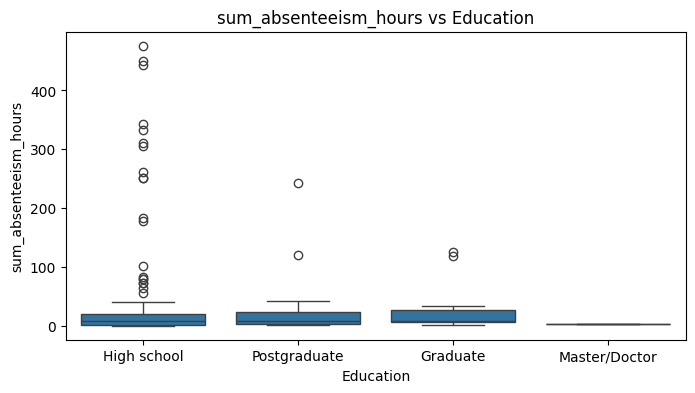

Education - p-value Kruskal-Wallis: 0.7065


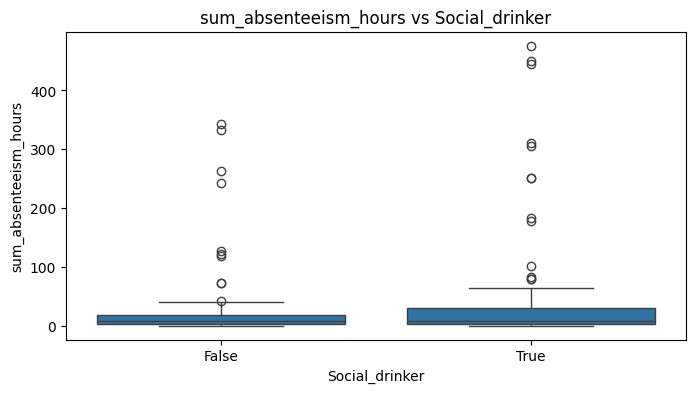

Social_drinker - p-value Mann-Whitney U: 0.2945


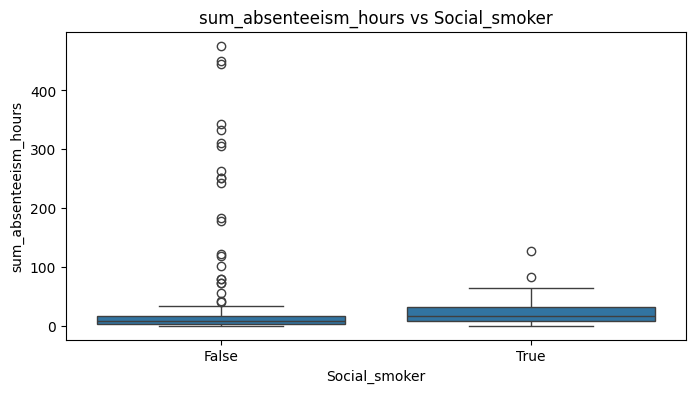

Social_smoker - p-value Mann-Whitney U: 0.1374


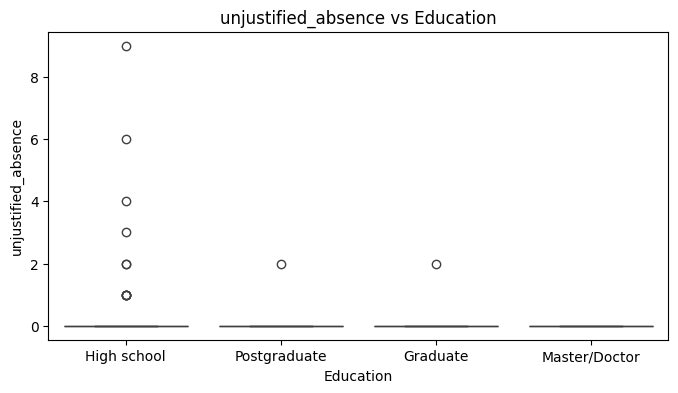

Education - p-value Kruskal-Wallis: 0.9784


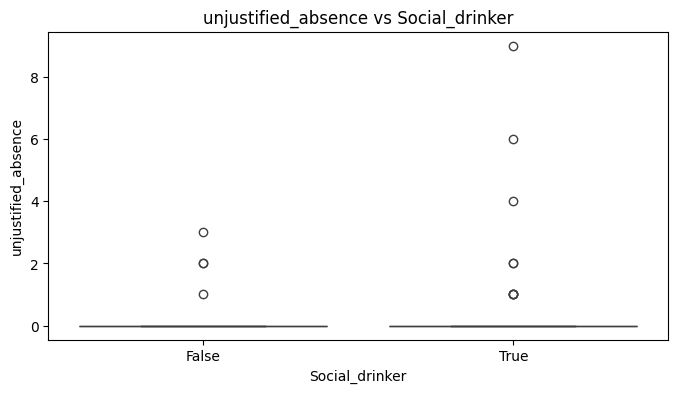

Social_drinker - p-value Mann-Whitney U: 0.2200


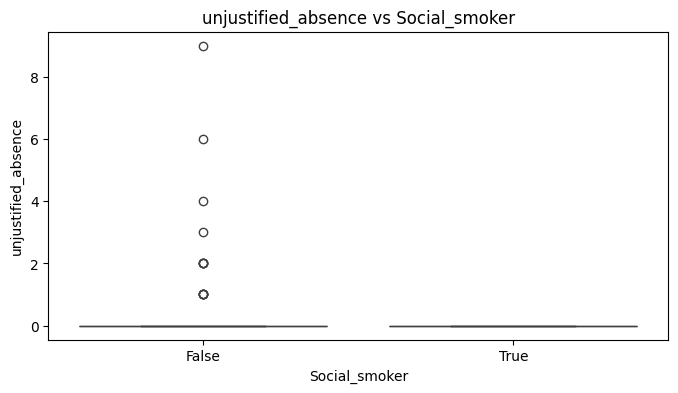

Social_smoker - p-value Mann-Whitney U: 0.1559


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Lista de targets y variables categóricas
targets = ["medida_desempeno", "Hit_target_avg","sum_absenteeism_hours","unjustified_absence"] 
cat_vars = ['Education', 'Social_drinker', 'Social_smoker']

# Función para graficar y aplicar test estadístico
def analyze_categorical(target, cat_vars, df):
    for col in cat_vars:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=col, y=target, data=df)
        plt.title(f"{target} vs {col}")
        plt.show()

        # Separar en grupos según la categoría
        groups = [group[target].values for name, group in df.groupby(col)]

        # Aplicar test estadístico según tipo de variable
        if col == "Education" and len(groups) > 1:
            kruskal = stats.kruskal(*groups)
            print(f"{col} - p-value Kruskal-Wallis: {kruskal.pvalue:.4f}")
        elif len(groups) == 2:
            mannwhitney = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
            print(f"{col} - p-value Mann-Whitney U: {mannwhitney.pvalue:.4f}")
        else:
            print(f"{col} - No se ha aplicado test estadístico")

# Ejecutar para todos los targets
for target in targets:
    analyze_categorical(target, cat_vars, df)



### Relación entre variables categóricas y Disciplinary_failure

In [ ]:
tabla_frec = pd.crosstab(df["Disciplinary_failure"], df["Social_drinker"])
from scipy.stats import chi2_contingency, fisher_exact
# Test Chi-cuadrado de independencia
chi2, p, dof, expected = chi2_contingency(tabla_frec)
print("\nResultados Chi-cuadrado:")
print(f"Chi2 = {chi2:.3f}")
print(f"Grados de libertad = {dof}")
print(f"p-valor = {p:.4f}")



Resultados Chi-cuadrado:
Chi2 = 0.022
Grados de libertad = 1
p-valor = 0.8821

Residuos estandarizados:
Social_drinker           False      True
Disciplinary_failure                    
False                 0.112933 -0.106474
True                 -0.250319  0.236003


In [33]:
tabla_frec = pd.crosstab(df["Disciplinary_failure"], df["Social_smoker"])
from scipy.stats import chi2_contingency, fisher_exact
# Test Chi-cuadrado de independencia
chi2, p, dof, expected = chi2_contingency(tabla_frec)
print("\nResultados Chi-cuadrado:")
print(f"Chi2 = {chi2:.3f}")
print(f"Grados de libertad = {dof}")
print(f"p-valor = {p:.4f}")



Resultados Chi-cuadrado:
Chi2 = 1.263
Grados de libertad = 1
p-valor = 0.2610


In [34]:
tabla_frec = pd.crosstab(df["Disciplinary_failure"], df["Education"])
from scipy.stats import chi2_contingency, fisher_exact
# Test Chi-cuadrado de independencia
chi2, p, dof, expected = chi2_contingency(tabla_frec)
print("\nResultados Chi-cuadrado:")
print(f"Chi2 = {chi2:.3f}")
print(f"Grados de libertad = {dof}")
print(f"p-valor = {p:.4f}")



Resultados Chi-cuadrado:
Chi2 = 1.117
Grados de libertad = 3
p-valor = 0.7730


## Modelo predictivo

In [29]:
# Passar les categòriques/binomials a object
cat_vars = ['Education', 'Social_drinker', 'Social_smoker']
for col in cat_vars:
    df[col] = df[col].astype(str).str.strip()

In [30]:
import numpy as np
import statsmodels.formula.api as smf

# 1. Escalar la resposta a [0,1]
df["medida_desempeno_scaled"] = df["medida_desempeno"] / 100

# 2. Ajustar els valors per evitar 0 i 1 exactes (sinó el logit peta)
eps = 1e-6
df["medida_desempeno_scaled"] = df["medida_desempeno_scaled"].clip(eps, 1 - eps)

# 3. Transformació logit
df["medida_desempeno_logit"] = np.log(df["medida_desempeno_scaled"] / (1 - df["medida_desempeno_scaled"]))

# 4. Definir la fórmula del model amb predictors
formula = 'medida_desempeno_logit ~  Transportation_expense + Distance_Residence_Work + Service_time + Age + Work_load_Average_day + Son + Weight + Height + Body_mass_index + Education + Social_drinker + Social_smoker'

# 5. Ajustar regressió lineal (OLS)
model = smf.glm(formula, data=df).fit()

# 6. Resultats
print(model.summary())

# 7. Si vols prediccions en l'escala original (0-100):
df["pred_logit"] = model.predict(df)
df["pred_scaled"] = 1 / (1 + np.exp(-df["pred_logit"]))  # inverse logit
df["pred_original"] = df["pred_scaled"] * 100

                   Generalized Linear Model Regression Results                    
Dep. Variable:     medida_desempeno_logit   No. Observations:                  136
Model:                                GLM   Df Residuals:                      121
Model Family:                    Gaussian   Df Model:                           14
Link Function:                   Identity   Scale:                          2.5416
Method:                              IRLS   Log-Likelihood:                -248.46
Date:                    Wed, 01 Oct 2025   Deviance:                       307.54
Time:                            23:12:49   Pearson chi2:                     308.
No. Iterations:                         3   Pseudo R-squ. (CS):             0.1673
Covariance Type:                nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------